INTEGRANTES:
- Ericka Cori
- Paolo Ramos
- Gaston Nina

# 1. Selección y Preprocesamiento del Dataset

El grupo decidio trabajar con el dataset de

# Importaciones y carga de los datos

In [380]:
# Imports
import pandas as pd
import numpy as np
import statsmodels.api as sm
from collections import Counter  # Contador de clases
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# Plot basico
plt.rcParams["figure.figsize"] = (10, 6)
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

In [381]:


# ruta de los archivos
path_data_sinan = "sinan-db.csv"
path_data_recife = "recife-db.csv"
path_data_attr = "attributes.csv"

sinan_df = pd.read_csv(path_data_sinan, index_col=0) # para evitar unamed
recife_df = pd.read_csv(path_data_recife, index_col=0)
attr_df = pd.read_csv(path_data_attr)

print("=== SINAN ===")
print("SINAN shape:", sinan_df.shape)
display(sinan_df.head())

print("=== recife ===")
print("recife shape:", recife_df.shape)
display(recife_df.head())


print("=== ATTRIBUTES ===")
print("Attributes shape:", attr_df.shape)
display(attr_df.head(50))

/tmp/ipykernel_7764/1803783339.py:6: DtypeWarning: Columns (14,31,53,54,55,59,61,63,89,100,116,135,136,137) have mixed types. Specify dtype option on import or set low_memory=False.
  sinan_df = pd.read_csv(path_data_sinan, index_col=0) # para evitar unamed
/tmp/ipykernel_7764/1803783339.py:7: DtypeWarning: Columns (1,27,31,53,54,55,60,61,88,97,113) have mixed types. Specify dtype option on import or set low_memory=False.
  recife_df = pd.read_csv(path_data_recife, index_col=0)


=== SINAN ===
SINAN shape: (57445, 146)


,NU_NOTIFIC,TP_NOT,ID_AGRAVO,DT_NOTIFIC,SEM_NOT,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,ID_UNIDADE,DT_SIN_PRI,SEM_PRI,DT_NASC,SOUNDEX,NU_IDADE_N,CS_SEXO,CS_GESTANT,CS_RACA,CS_ESCOL_N,SG_UF,ID_MN_RESI,ID_RG_RESI,ID_DISTRIT,ID_BAIRRO,NM_BAIRRO,ID_GEO1,ID_GEO2,CS_ZONA,ID_PAIS,DT_INVEST,ID_OCUPA_N,FEBRE,MIALGIA,CEFALEIA,EXANTEMA,VOMITO,NAUSEA,DOR_COSTAS,CONJUNTVIT,ARTRITE,ARTRALGIA,PETEQUIA_N,LEUCOPENIA,LACO,DOR_RETRO,DIABETES,HEMATOLOG,HEPATOPAT,RENAL,HIPERTENSA,ACIDO_PEPT,AUTO_IMUNE,DT_CHIK_S1,DT_CHIK_S2,DT_PRNT,RES_CHIKS1,RES_CHIKS2,RESUL_PRNT,DT_SORO,RESUL_SORO,DT_NS1,RESUL_NS1,DT_VIRAL,RESUL_VI_N,DT_PCR,RESUL_PCR_,SOROTIPO,HISTOPA_N,IMUNOH_N,HOSPITALIZ,DT_INTERNA,UF,MUNICIPIO,HOSPITAL,DDD_HOSP,TEL_HOSP,TPAUTOCTO,COUFINF,COPAISINF,COMUNINF,CODISINF,CO_BAINF,NOBAIINF,CLASSI_FIN,CRITERIO,DOENCA_TRA,CLINC_CHIK,EVOLUCAO,DT_OBITO,DT_ENCERRA,ALRM_HIPOT,ALRM_PLAQ,ALRM_VOM,ALRM_SANG,ALRM_HEMAT,ALRM_ABDOM,ALRM_LETAR,ALRM_HEPAT,ALRM_LIQ,DT_ALRM,GRAV_PULSO,GRAV_CONV,GRAV_ENCH,GRAV_INSUF,GRAV_TAQUI,GRAV_EXTRE,GRAV_HIPOT,GRAV_HEMAT,GRAV_MELEN,GRAV_METRO,GRAV_SANG,GRAV_AST,GRAV_MIOC,GRAV_CONSC,GRAV_ORGAO,DT_GRAV,MANI_HEMOR,EPISTAXE,GENGIVO,METRO,PETEQUIAS,HEMATURA,SANGRAM,LACO_N,PLASMATICO,EVIDENCIA,PLAQ_MENOR,CON_FHD,COMPLICA,NU_LOTE_I,DS_OBS,TP_SISTEMA,NDUPLIC_N,DT_DIGITA,DT_TRANSUS,DT_TRANSDM,DT_TRANSSM,DT_TRANSRM,DT_TRANSRS,DT_TRANSSE,NU_LOTE_V,NU_LOTE_H,CS_FLXRET,FLXRECEBI,IDENT_MICR,MIGRADO_W
0,50375,2,A90,01/06/2015,201522,2015,13,130040,5584.0,2015277,25/05/2015,201521.0,25/01/2014,NaN,4001,M,6.0,4.0,10.0,13.0,130040.0,5584.0,NaN,192.0,CENTRO,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,NaN,NaN,NaN,NaN,NaN,01/08/2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,09/06/2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,4.0,NaN
1,50398,2,A90,08/06/2015,201523,2015,13,130040,5584.0,5362911,29/05/2015,201521.0,03/03/1945,NaN,4070,F,5.0,4.0,1.0,13.0,130040.0,5584.0,NaN,192.0,CENTRO,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,NaN,NaN,NaN,NaN,NaN,08/08/2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,16/06/2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,4.0,NaN
2,50381,2,A90,08/06/2015,201523,2015,13,130040,5584.0,2015269,02/06/2015,201522.0,01/03/1985,NaN,4030,F,5.0,4.0,6.0,13.0,130040.0,5584.0,NaN,192.0,CENTRO,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,NaN,NaN,NaN,NaN,NaN,08/08/2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,10/06/2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,4.0,NaN
3,50352,2,A90,11/05/2015,201519,2015,13,130040,5584.0,5362911,07/05/2015,201518.0,12/10/2004,NaN,4010,F,6.0,4.0,3.0,13.0,130040.0,5584.0,NaN,192.0,CENTRO,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,NaN,NaN,NaN,NaN,NaN,11/07/2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,09/06/2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

=== recife ===
recife shape: (83073, 124)


,nu_notificacao,tp_notificacao,co_cid,dt_notificacao,ds_semana_notificacao,notificacao_ano,co_uf_notificacao,co_municipio_notificacao,id_regional,co_unidade_notificacao,dt_diagnostico_sintoma,ds_semana_sintoma,dt_nascimento,nu_idade,tp_sexo,tp_gestante,tp_raca_cor,tp_escolaridade,co_uf_residencia,co_municipio_residencia,co_regional_residencia,co_distrito_residencia,co_bairro_residencia,no_bairro_residencia,co_logradouro_residencia,nome_logradouro_residencia,nu_cep_residencia,tp_zona_residencia,co_pais_residencia,dt_investigacao,co_cbo_ocupacao,febre,mialgia,cefaleia,exantema,vomito,nausea,dor_costas,conjutivite,artrite,artralgia,petequia_n,leucopenia,laco,dor_retro,diabetes,hematolog,hepatopat,renal,hipertensao,acido_pept,auto_imune,dt_chil_s1,dt_chil_s2,dt_prnt,res_chiks1,res_chiks2,resul_prnt,dt_coleta_exame,tp_result_exame,dt_coleta_NS1,Tp_result_NS1,dt_coleta_isolamento,tp_result_isolamento,dt_coleta_rtpcr,tp_result_rtpcr,tp_sorotipo,tp_result_histopatologia,tp_result_imunohistoquimica,st_ocorreu_hospitalizacao,dt_internacao,co_uf_hospital,co_municipio_hospital,tp_autoctone_residencia,co_uf_infeccao,co_pais_infeccao,co_municipio_infeccao,co_distrito_infeccao,co_bairro_infeccao,no_bairro_infeccao,tp_classificacao_final,tp_criterio_confirmacao,st_doenca_trabalho,clinc_chik,tp_evolucao_caso,dt_obito,dt_encerramento,alrm_hipot,alrm_plaq,alrm_vom,alrm_sang,alrm_hemat,alrm_abdom,alrm_letar,alrm_hepat,alrm_liq,dt_alrm,grav_pulso,grav_conv,grav_ench,grav_insuf,grav_taqui,grav_extre,grav_hipot,grav_hemat,grav_melen,grav_metro,grav_sang,grav_ast,grav_mioc,grav_consc,grav_orgao,dt_grav,epistaxe,gengivo,metro,petequias,hematura,sangram,laco_n,plasmatico,evidencia,plaq_menor,complica
0,2126258,2.0,A90,2015-12-10,201549.0,2015.0,26.0,261160.0,1497.0,930.0,2015-12-10,201549.0,2002-06,3006.0,M,6.0,9.0,10.0,26.0,261160.0,1497.0,122.0,26.0,IMBIRIBEIRA,NaN,R NOSSA SENHORA DO CARMO,NaN,1.0,1.0,2015-12-10,NaN,1.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,NaN,NaN,NaN,NaN,NaN,2016-02-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1562314,2.0,A90,2015-01-21,201503.0,2015.0,26.0,261160.0,1497.0,6468918.0,2015-01-09,201501.0,1987-10,4027.0,M,6.0,9.0,NaN,26.0,261160.0,1497.0,117.0,10.0,SANTO AMARO,NaN,RUA FREI CASSIMIRO,NaN,1.0,1.0,2015-01-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,2.0,NaN,NaN,1.0,NaN,2015-03-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1758636,2.0,A90,2015-01-06,201501.0,2015.0,26.0,260960.0,1497.0,2345021.0,2015-01-06,201501.0,1964-05,4050.0,F,6.0,9.0,NaN,26.0,261160.0,1497.0,NaN,10.0,SANTO AMARO,NaN,RUA CAMPO DA VOVOZINHA,NaN,1.0,1.0,2015-02-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,2.0,NaN,NaN,1.0,NaN,2015-02-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2127412,2.0,A90,2015-10-26,201543.0,2015.0,26.0,261160.0,1497.0,20516.0,2015-01-05,201501.0,2011-01,4004.0,M,6.0,9.0,10.0,26.0,261160.0,1497.0,117.0,10.0,SANTO AMARO,NaN,RUA TUPINIQUIM,NaN,1.0,1.0,2015-11-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,26.0,1.0,261160.0,117.0,10.0,SANTO AMARO,10.0,2.0,2.0,NaN,1.0,NaN,2015-11-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

=== ATTRIBUTES ===
Attributes shape: (69, 3)


,Attribute,Description,Value
0,NU_IDADE_N,Patient age,The attribute's order of magnitude is defined ...
1,NaN,NaN,1. Hour
2,NaN,NaN,2. Day
3,NaN,NaN,3. Month
4,NaN,NaN,4. Year
5,NaN,NaN,Ex. 3009 -> 9 months | 4021 -> 21 years old
6,CS_SEXO,Pacient sex,1. Male
7,NaN,NaN,2. Female
8,CS_GESTANT,Gestational Age of the Patient (Quarter) in ca...,1. 1st Quarter
9,NaN,NaN,2. 2nd Quarter


por lo anterior podemos definir que tenian edades mezcladas ejemplo
el valor NU_IDADE=4022

4 → unidad = años
022 → edad = 22
22 años

---
3009

3 → meses
009 → 9 meses


# Lectura de los conjuntos de datos
## Recife-db

Recife-db originalmente tiene una nomenclatura diferente a la base de datos sinan-db. Sin embargo, en el diccionario de datos es posible ver ambas nomenclaturas, por lo que primero se renombraron las columnas de recife-db para que correspondan con sus equivalentes en sinan-db.

In [382]:
columns = {
    "nu_notificacao": "NU_NOTIFIC",
    "tp_notificacao": "TP_NOT",
    "dt_notificacao": "DT_NOTIFIC",
    "ds_semana_notificacao": "SEM_NOT",
    "notificacao_ano": "NU_ANO",
    "co_uf_notificacao": "SG_UF_NOT",
    "co_municipio_notificacao": "ID_MUNICIP",
    "id_regional": "ID_REGIONA",
    "co_unidade_notificacao": "ID_UNIDADE",
    "dt_diagnostico_sintoma": "DT_SIN_PRI",
    "ds_semana_sintoma": "SEM_PRI",
    "dt_nascimento": "DT_NASC",
    "nu_idade": "NU_IDADE_N",
    "tp_sexo": "CS_SEXO",
    "tp_gestante": "CS_GESTANT",
    "tp_raca_cor": "CS_RACA",
    "tp_escolaridade": "CS_ESCOL_N",
    "co_uf_residencia": "SG_UF",
    "co_municipio_residencia": "ID_MN_RESI",
    "co_regional_residencia": "ID_RG_RESI",
    "co_distrito_residencia": "ID_DISTRIT",
    "co_bairro_residencia": "ID_BAIRRO",
    "no_bairro_residencia": "NM_BAIRRO",
    "tp_zona_residencia": "CS_ZONA",
    "co_pais_residencia": "ID_PAIS",
    "dt_investigacao": "DT_INVEST",
    "co_cbo_ocupacao": "ID_OCUPA_N",
    "febre": "FEBRE",
    "mialgia": "MIALGIA",
    "cefaleia": "CEFALEIA",
    "exantema": "EXANTEMA",
    "vomito": "VOMITO",
    "nausea": "NAUSEA",
    "dor_costas": "DOR_COSTAS",
    "conjutivite": "CONJUNTVIT",
    "artrite": "ARTRITE",
    "artralgia": "ARTRALGIA",
    "petequia_n": "PETEQUIA_N",
    "leucopenia": "LEUCOPENIA",
    "laco": "LACO",
    "dor_retro": "DOR_RETRO",
    "diabetes": "DIABETES",
    "hematolog": "HEMATOLOG",
    "hepatopat": "HEPATOPAT",
    "renal": "RENAL",
    "hipertensao": "HIPERTENSA",
    "acido_pept": "ACIDO_PEPT",
    "auto_imune": "AUTO_IMUNE",
    "dt_chil_s1": "DT_CHIK_S1",
    "dt_chil_s2": "DT_CHIK_S2",
    "dt_prnt": "DT_PRNT",
    "res_chiks1": "RES_CHIKS1",
    "res_chiks2": "RES_CHIKS2",
    "resul_prnt": "RESUL_PRNT",
    "dt_coleta_exame": "DT_SORO",
    "tp_result_exame": "RESUL_SORO",
    "dt_coleta_NS1": "DT_NS1",
    "Tp_result_NS1": "RESUL_NS1",
    "dt_coleta_isolamento": "DT_VIRAL",
    "tp_result_isolamento": "RESUL_VI_N",
    "dt_coleta_rtpcr": "DT_PCR",
    "tp_result_rtpcr": "RESUL_PCR_",
    "tp_sorotipo": "SOROTIPO",
    "tp_result_histopatologia": "HISTOPA_N",
    "tp_result_imunohistoquimica": "IMUNOH_N",
    "st_ocorreu_hospitalizacao": "HOSPITALIZ",
    "dt_internacao": "DT_INTERNA",
    "co_uf_hospital": "UF",
    "co_municipio_hospital": "MUNICIPIO",
    "tp_autoctone_residencia": "TPAUTOCTO",
    "co_uf_infeccao": "COUFINF",
    "co_pais_infeccao": "COPAISINF",
    "co_municipio_infeccao": "COMUNINF",
    "co_distrito_infeccao": "CODISINF",
    "co_bairro_infeccao": "CO_BAINF",
    "no_bairro_infeccao": "NOBAIINF",
    "tp_classificacao_final": "CLASSI_FIN",
    "tp_criterio_confirmacao": "CRITERIO",
    "st_doenca_trabalho": "DOENCA_TRA",
    "clinc_chik": "CLINC_CHIK",
    "tp_evolucao_caso": "EVOLUCAO",
    "dt_obito": "DT_OBITO",
    "dt_encerramento": "DT_ENCERRA",
    "alrm_hipot": "ALRM_HIPOT",
    "alrm_plaq": "ALRM_PLAQ",
    "alrm_vom": "ALRM_VOM",
    "alrm_sang": "ALRM_SANG",
    "alrm_hemat": "ALRM_HEMAT",
    "alrm_abdom": "ALRM_ABDOM",
    "alrm_letar": "ALRM_LETAR",
    "alrm_hepat": "ALRM_HEPAT",
    "alrm_liq": "ALRM_LIQ",
    "dt_alrm": "DT_ALRM",
    "grav_pulso": "GRAV_PULSO",
    "grav_conv": "GRAV_CONV",
    "grav_ench": "GRAV_ENCH",
    "grav_insuf": "GRAV_INSUF",
    "grav_taqui": "GRAV_TAQUI",
    "grav_extre": "GRAV_EXTRE",
    "grav_hipot": "GRAV_HIPOT",
    "grav_hemat": "GRAV_HEMAT",
    "grav_melen": "GRAV_MELEN",
    "grav_metro": "GRAV_METRO",
    "grav_sang": "GRAV_SANG",
    "grav_ast": "GRAV_AST",
    "grav_mioc": "GRAV_MIOC",
    "grav_consc": "GRAV_CONSC",
    "grav_orgao": "GRAV_ORGAO",
    "dt_grav": "DT_GRAV",
    "mami_hemor": "MANI_HEMOR",
    "epistaxe": "EPISTAXE",
    "gengivo": "GENGIVO",
    "metro": "METRO",
    "petequias": "PETEQUIAS",
    "hematura": "HEMATURA",
    "sangram": "SANGRAM",
    "laco_n": "LACO_N",
    "plasmatico": "PLASMATICO",
    "evidencia": "EVIDENCIA",
    "plaq_menor": "PLAQ_MENOR",
    "complica": "COMPLICA"
}

recife_df.rename(columns=columns, inplace=True)
recife_df.head()

,NU_NOTIFIC,TP_NOT,co_cid,DT_NOTIFIC,SEM_NOT,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,ID_UNIDADE,DT_SIN_PRI,SEM_PRI,DT_NASC,NU_IDADE_N,CS_SEXO,CS_GESTANT,CS_RACA,CS_ESCOL_N,SG_UF,ID_MN_RESI,ID_RG_RESI,ID_DISTRIT,ID_BAIRRO,NM_BAIRRO,co_logradouro_residencia,nome_logradouro_residencia,nu_cep_residencia,CS_ZONA,ID_PAIS,DT_INVEST,ID_OCUPA_N,FEBRE,MIALGIA,CEFALEIA,EXANTEMA,VOMITO,NAUSEA,DOR_COSTAS,CONJUNTVIT,ARTRITE,ARTRALGIA,PETEQUIA_N,LEUCOPENIA,LACO,DOR_RETRO,DIABETES,HEMATOLOG,HEPATOPAT,RENAL,HIPERTENSA,ACIDO_PEPT,AUTO_IMUNE,DT_CHIK_S1,DT_CHIK_S2,DT_PRNT,RES_CHIKS1,RES_CHIKS2,RESUL_PRNT,DT_SORO,RESUL_SORO,DT_NS1,RESUL_NS1,DT_VIRAL,RESUL_VI_N,DT_PCR,RESUL_PCR_,SOROTIPO,HISTOPA_N,IMUNOH_N,HOSPITALIZ,DT_INTERNA,UF,MUNICIPIO,TPAUTOCTO,COUFINF,COPAISINF,COMUNINF,CODISINF,CO_BAINF,NOBAIINF,CLASSI_FIN,CRITERIO,DOENCA_TRA,CLINC_CHIK,EVOLUCAO,DT_OBITO,DT_ENCERRA,ALRM_HIPOT,ALRM_PLAQ,ALRM_VOM,ALRM_SANG,ALRM_HEMAT,ALRM_ABDOM,ALRM_LETAR,ALRM_HEPAT,ALRM_LIQ,DT_ALRM,GRAV_PULSO,GRAV_CONV,GRAV_ENCH,GRAV_INSUF,GRAV_TAQUI,GRAV_EXTRE,GRAV_HIPOT,GRAV_HEMAT,GRAV_MELEN,GRAV_METRO,GRAV_SANG,GRAV_AST,GRAV_MIOC,GRAV_CONSC,GRAV_ORGAO,DT_GRAV,EPISTAXE,GENGIVO,METRO,PETEQUIAS,HEMATURA,SANGRAM,LACO_N,PLASMATICO,EVIDENCIA,PLAQ_MENOR,COMPLICA
0,2126258,2.0,A90,2015-12-10,201549.0,2015.0,26.0,261160.0,1497.0,930.0,2015-12-10,201549.0,2002-06,3006.0,M,6.0,9.0,10.0,26.0,261160.0,1497.0,122.0,26.0,IMBIRIBEIRA,NaN,R NOSSA SENHORA DO CARMO,NaN,1.0,1.0,2015-12-10,NaN,1.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,NaN,NaN,NaN,NaN,NaN,2016-02-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1562314,2.0,A90,2015-01-21,201503.0,2015.0,26.0,261160.0,1497.0,6468918.0,2015-01-09,201501.0,1987-10,4027.0,M,6.0,9.0,NaN,26.0,261160.0,1497.0,117.0,10.0,SANTO AMARO,NaN,RUA FREI CASSIMIRO,NaN,1.0,1.0,2015-01-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,2.0,NaN,NaN,1.0,NaN,2015-03-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1758636,2.0,A90,2015-01-06,201501.0,2015.0,26.0,260960.0,1497.0,2345021.0,2015-01-06,201501.0,1964-05,4050.0,F,6.0,9.0,NaN,26.0,261160.0,1497.0,NaN,10.0,SANTO AMARO,NaN,RUA CAMPO DA VOVOZINHA,NaN,1.0,1.0,2015-02-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,2.0,NaN,NaN,1.0,NaN,2015-02-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2127412,2.0,A90,2015-10-26,201543.0,2015.0,26.0,261160.0,1497.0,20516.0,2015-01-05,201501.0,2011-01,4004.0,M,6.0,9.0,10.0,26.0,261160.0,1497.0,117.0,10.0,SANTO AMARO,NaN,RUA TUPINIQUIM,NaN,1.0,1.0,2015-11-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,26.0,1.0,261160.0,117.0,10.0,SANTO AMARO,10.0,2.0,2.0,NaN,1.0,NaN,2015-11-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1562589,2.0,A90,2015-01-19,201503.0,2015.0,26.0,261160.0,1497.0,6703437.0,2015-01-07,201501.0,1989-08,4025.0,F,5.0,9.0,9.0,26.0,261160.0,1497.0,117.0,10.0,SANTO AMARO,NaN,RUA JOAQUIM RABELO,50110060.0,1.0,1.0,2015-03-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015-03-03,1.0,NaN,NaN,NaN,

# Unificación de los 2 datasets

In [383]:
display(sinan_df.dtypes)

,0
NU_NOTIFIC,int64
TP_NOT,int64
ID_AGRAVO,object
DT_NOTIFIC,object
SEM_NOT,int64
...,...
NU_LOTE_H,float64
CS_FLXRET,float64
FLXRECEBI,float64
IDENT_MICR,float64


In [384]:
df = pd.concat([sinan_df, recife_df], join='inner')
df.head()

,NU_NOTIFIC,TP_NOT,DT_NOTIFIC,SEM_NOT,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,ID_UNIDADE,DT_SIN_PRI,SEM_PRI,DT_NASC,NU_IDADE_N,CS_SEXO,CS_GESTANT,CS_RACA,CS_ESCOL_N,SG_UF,ID_MN_RESI,ID_RG_RESI,ID_DISTRIT,ID_BAIRRO,NM_BAIRRO,CS_ZONA,ID_PAIS,DT_INVEST,ID_OCUPA_N,FEBRE,MIALGIA,CEFALEIA,EXANTEMA,VOMITO,NAUSEA,DOR_COSTAS,CONJUNTVIT,ARTRITE,ARTRALGIA,PETEQUIA_N,LEUCOPENIA,LACO,DOR_RETRO,DIABETES,HEMATOLOG,HEPATOPAT,RENAL,HIPERTENSA,ACIDO_PEPT,AUTO_IMUNE,DT_CHIK_S1,DT_CHIK_S2,DT_PRNT,RES_CHIKS1,RES_CHIKS2,RESUL_PRNT,DT_SORO,RESUL_SORO,DT_NS1,RESUL_NS1,DT_VIRAL,RESUL_VI_N,DT_PCR,RESUL_PCR_,SOROTIPO,HISTOPA_N,IMUNOH_N,HOSPITALIZ,DT_INTERNA,UF,MUNICIPIO,TPAUTOCTO,COUFINF,COPAISINF,COMUNINF,CODISINF,CO_BAINF,NOBAIINF,CLASSI_FIN,CRITERIO,DOENCA_TRA,CLINC_CHIK,EVOLUCAO,DT_OBITO,DT_ENCERRA,ALRM_HIPOT,ALRM_PLAQ,ALRM_VOM,ALRM_SANG,ALRM_HEMAT,ALRM_ABDOM,ALRM_LETAR,ALRM_HEPAT,ALRM_LIQ,DT_ALRM,GRAV_PULSO,GRAV_CONV,GRAV_ENCH,GRAV_INSUF,GRAV_TAQUI,GRAV_EXTRE,GRAV_HIPOT,GRAV_HEMAT,GRAV_MELEN,GRAV_METRO,GRAV_SANG,GRAV_AST,GRAV_MIOC,GRAV_CONSC,GRAV_ORGAO,DT_GRAV,EPISTAXE,GENGIVO,METRO,PETEQUIAS,HEMATURA,SANGRAM,LACO_N,PLASMATICO,EVIDENCIA,PLAQ_MENOR,COMPLICA
0,50375,2.0,01/06/2015,201522.0,2015.0,13.0,130040.0,5584.0,2015277.0,25/05/2015,201521.0,25/01/2014,4001.0,M,6.0,4.0,10.0,13.0,130040.0,5584.0,NaN,192.0,CENTRO,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,NaN,NaN,NaN,NaN,NaN,01/08/2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,50398,2.0,08/06/2015,201523.0,2015.0,13.0,130040.0,5584.0,5362911.0,29/05/2015,201521.0,03/03/1945,4070.0,F,5.0,4.0,1.0,13.0,130040.0,5584.0,NaN,192.0,CENTRO,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,NaN,NaN,NaN,NaN,NaN,08/08/2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,50381,2.0,08/06/2015,201523.0,2015.0,13.0,130040.0,5584.0,2015269.0,02/06/2015,201522.0,01/03/1985,4030.0,F,5.0,4.0,6.0,13.0,130040.0,5584.0,NaN,192.0,CENTRO,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,NaN,NaN,NaN,NaN,NaN,08/08/2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,50352,2.0,11/05/2015,201519.0,2015.0,13.0,130040.0,5584.0,5362911.0,07/05/2015,201518.0,12/10/2004,4010.0,F,6.0,4.0,3.0,13.0,130040.0,5584.0,NaN,192.0,CENTRO,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,NaN,NaN,NaN,NaN,NaN,11/07/2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,50328,2.0,11/05/2015,201519.0,2015.0,13.0,130040.0,5584.0,5362911.0,07/05/2015,201518.0,21/01/2007,4008.0,M,6.0,4.0,2.0,13.0,130040.0,5584.0,NaN,192.0,CENTRO,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,NaN,NaN,NaN,NaN,NaN,11/07/2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [385]:
print("=== DF INFO ===")
df.info()

=== DF INFO ===
<class 'pandas.core.frame.DataFrame'>
Index: 140518 entries, 0 to 277
Columns: 120 entries, NU_NOTIFIC to COMPLICA
dtypes: float64(97), object(23)
memory usage: 129.7+ MB


In [386]:
df.describe()

,TP_NOT,SEM_NOT,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,ID_UNIDADE,SEM_PRI,NU_IDADE_N,CS_GESTANT,CS_RACA,CS_ESCOL_N,SG_UF,ID_MN_RESI,ID_RG_RESI,ID_DISTRIT,ID_BAIRRO,CS_ZONA,ID_PAIS,FEBRE,MIALGIA,CEFALEIA,EXANTEMA,VOMITO,NAUSEA,DOR_COSTAS,CONJUNTVIT,ARTRITE,ARTRALGIA,PETEQUIA_N,LEUCOPENIA,LACO,DOR_RETRO,DIABETES,HEMATOLOG,HEPATOPAT,RENAL,HIPERTENSA,ACIDO_PEPT,AUTO_IMUNE,RES_CHIKS1,RES_CHIKS2,RESUL_PRNT,RESUL_NS1,RESUL_VI_N,RESUL_PCR_,SOROTIPO,HISTOPA_N,IMUNOH_N,HOSPITALIZ,UF,MUNICIPIO,TPAUTOCTO,COUFINF,COPAISINF,COMUNINF,CODISINF,CO_BAINF,CLASSI_FIN,CRITERIO,DOENCA_TRA,CLINC_CHIK,EVOLUCAO,ALRM_PLAQ,ALRM_VOM,ALRM_SANG,ALRM_HEMAT,ALRM_ABDOM,ALRM_LETAR,ALRM_HEPAT,ALRM_LIQ,GRAV_PULSO,GRAV_CONV,GRAV_ENCH,GRAV_INSUF,GRAV_TAQUI,GRAV_EXTRE,GRAV_HIPOT,GRAV_HEMAT,GRAV_MELEN,GRAV_METRO,GRAV_SANG,GRAV_AST,GRAV_MIOC,GRAV_CONSC,GRAV_ORGAO,EPISTAXE,GENGIVO,METRO,PETEQUIAS,HEMATURA,SANGRAM,LACO_N,PLASMATICO,EVIDENCIA,PLAQ_MENOR,COMPLICA
count,138143.000000,138143.000000,138143.000000,138143.000000,138143.000000,138107.000000,1.381430e+05,138142.000000,138143.000000,138117.000000,126285.000000,100231.000000,138133.000000,138139.000000,138137.000000,95418.000000,120378.000000,126521.000000,138139.000000,75951.000000,75952.000000,75952.000000,75952.000000,75952.000000,75952.000000,75952.000000,75952.000000,75952.000000,75952.000000,75952.000000,75952.000000,75952.000000,75952.000000,75952.000000,75952.000000,75952.000000,75952.000000,75952.000000,75952.000000,75952.000000,3873.000000,2327.000000,2308.000000,53472.000000,51718.000000,50180.000000,158.000000,41918.000000,42055.000000,73279.000000,3500.000000,3365.000000,39776.000000,33062.000000,33065.000000,32794.000000,12598.000000,16306.000000,137231.000000,121128.000000,22253.000000,10596.000000,109744.000000,336.000000,331.000000,336.000000,332.000000,338.000000,333.000000,332.000000,333.000000,50.000000,50.000000,50.000000,50.00000,50.000000,50.000000,50.000000,50.000000,50.00000,50.000000,51.000000,50.000000,50.0,50.000000,51.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,24.000000,1.0,11.000000,11.000000
mean,2.000007,201680.325330,2016.586559,20.609007,206852.741565,3177.197854,3.092890e+06,201675.600527,3994.113998,6.155361,6.004522,7.889206,20.594644,206733.568123,3195.897812,173.618238,104.362832,1.104228,1.000043,6.703796,1.423649,1.340478,1.719626,1.796292,1.764127,1.784561,1.954340,1.903005,1.674070,1.938777,1.957144,1.978263,1.811460,1.987189,1.996261,1.994773,1.996577,1.971903,1.994681,1.997103,2.736380,3.908466,3.935442,3.595115,3.988843,3.944360,1.449367,3.992772,3.990940,2.447413,20.519143,205755.198811,1.325674,20.486147,1.041131,205328.798744,180.574615,113.346008,7.687053,1.740456,2.316721,1.025481,1.252579,1.550595,1.703927,1.613095,1.936747,1.473373,1.861862,1.957831,1.894895,1.820000,1.900000,1.820000,1.70000,1.620000,1.640000,1.760000,1.820000,1.86000,1.900000,1.960784,1.900000,2.0,1.600000,1.803922,2.545455,2.363636,2.636364,1.545455,2.545455,2.454545,3.818182,3.125000,1.0,69550.363636,6.818182
std,0.002691,167.875647,1.656741,6.433535,64768.717376,2009.520646,2.600814e+06,189.874172,234.180992,1.296761,2.698164,2.455552,6.408238,64528.799312,2014.426064,132.466546,149.644778,0.810570,0.016143,1532.351192,0.494139,0.473873,0.449185,0.402757,0.424546,0.411129,0.208749,0.295954,0.468724,0.239740,0.202534,0.145826,0.391145,0.112458,0.061035,0.072109,0.058408,0.165250,0.072739,0.053742,1.259042,0.437644,0.359032,0.898281,0.145746,0.345753,0.993914,0.125177,0.137367,1.830971,6.560679,66127.926312,0.706533,6.436041,2.444410,64862.356937,141.264898,176.043256,2.833997,0.500121,1.477371,0.157589,1.383130,0.498175,0.457215,0.487768,0.243785,0.500031,0.345564,0.201277,0.307150,0.388088,0.303046,0.388088,0.46291,0.490314,0.484873,0.431419,0.388088,0.35051,0.303046,0.196039,0.303046,0.0,0.494872,0.400979,2.161649,2.248232,2.110579,0.522233,2.161649,2.207425,3.341203,2.691573,NaN,60416.238723,1.721522
min,2.000000,201453.000000,2015.000000,11.000000,11000

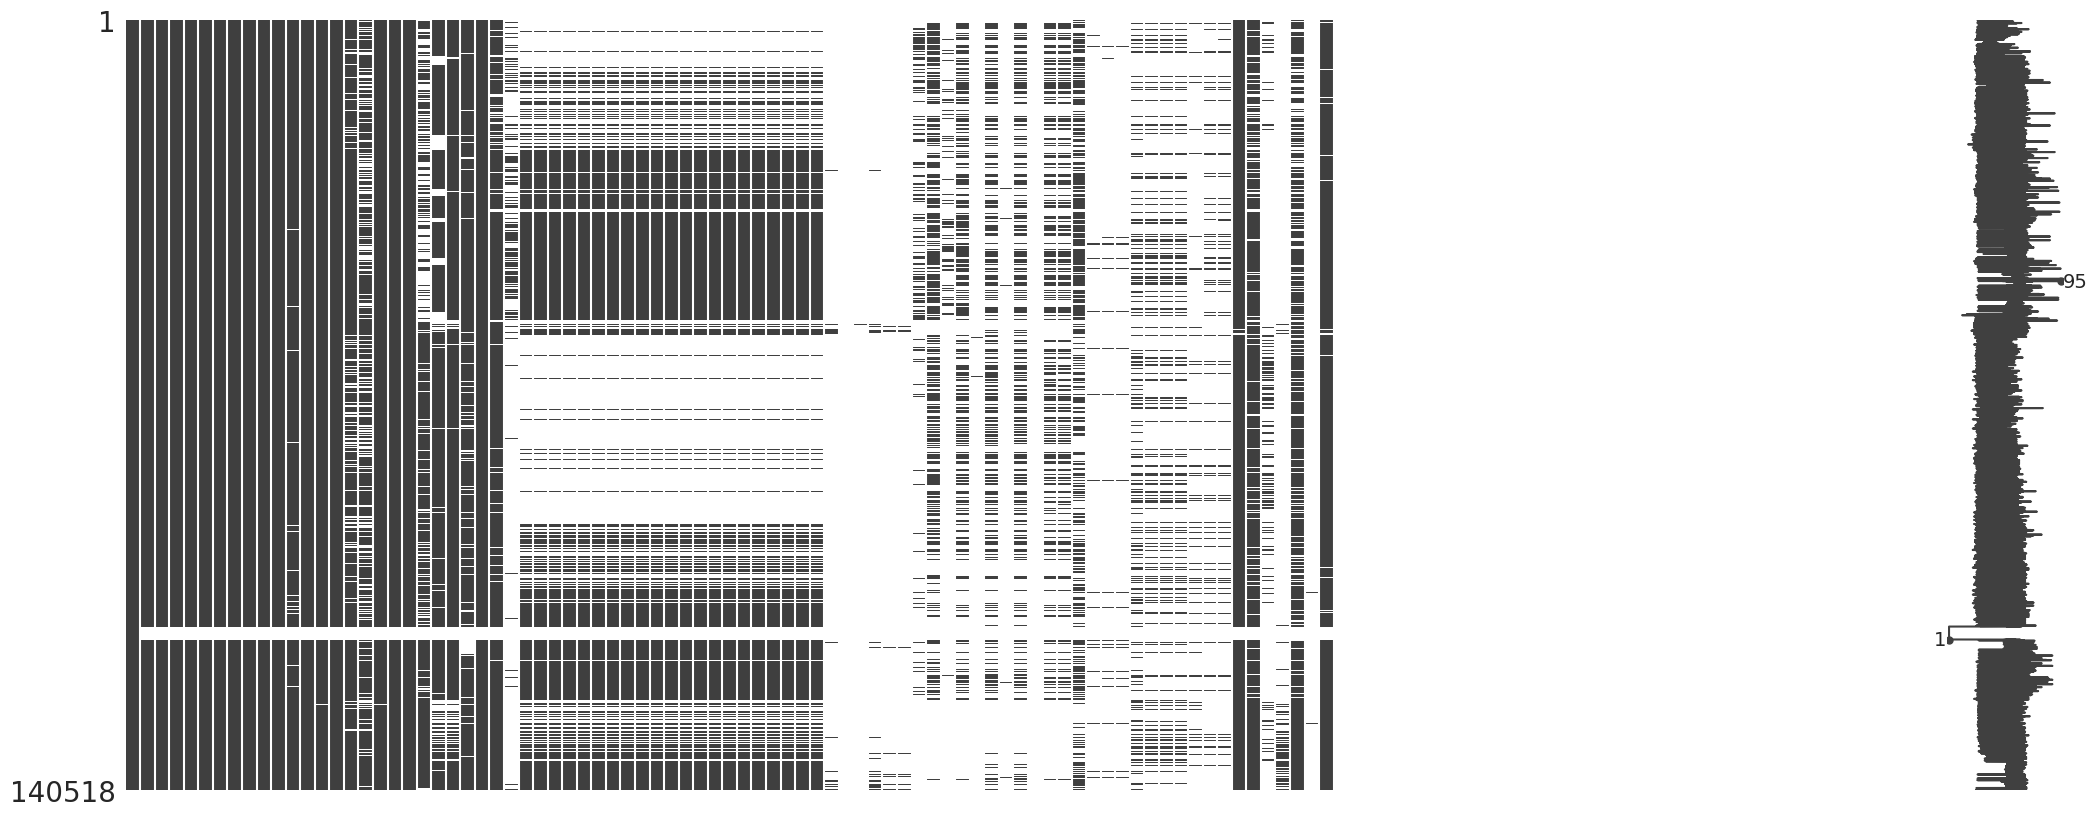

In [387]:
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(df)
plt.show()

In [388]:
df.isnull().sum().sort_values(ascending=False)

,0
EVIDENCIA,140517
METRO,140507
SANGRAM,140507
COMPLICA,140507
PLAQ_MENOR,140507
...,...
ID_MUNICIP,2375
ID_UNIDADE,2375
SEM_NOT,2375
SG_UF_NOT,2375


# Eliminación de filas vacías

In [389]:
# Usamos solo la columna FEVER como base, ya que observamos que cuando falta un síntoma, faltan todos.
df.dropna(subset=['FEBRE'], how='any', inplace=True)

# Eliminación de columnas vacías
Se eliminaron las columnas que tenían más del 50% de los datos nulos.

In [390]:
empty_columns = [
    'ID_DISTRIT',
    'ID_OCUPA_N',
    'DT_CHIK_S1',
    'DT_CHIK_S2',
    'DT_PRNT',
    'RESUL_PRNT',
    'DT_SORO',
    'DT_NS1',
    'DT_VIRAL',
    'DT_PCR',
    'RESUL_PCR_',
    'SOROTIPO',
    'HISTOPA_N',
    'IMUNOH_N',
    'DT_INTERNA',
    'UF',
    'MUNICIPIO',
    'TPAUTOCTO',
    'COUFINF',
    'COPAISINF',
    'COMUNINF',
    'CODISINF',
    'CO_BAINF',
    'NOBAIINF',
    'DOENCA_TRA',
    'DT_OBITO',
    'ALRM_HIPOT',
    'ALRM_PLAQ',
    'ALRM_VOM',
    'ALRM_SANG',
    'ALRM_HEMAT',
    'ALRM_ABDOM',
    'ALRM_LETAR',
    'ALRM_HEPAT',
    'ALRM_LIQ',
    'DT_ALRM',
    'DT_GRAV',
    'EPISTAXE',
    'GENGIVO',
    'METRO',
    'PETEQUIAS',
    'HEMATURA',
    'SANGRAM',
    'LACO_N',
    'PLASMATICO',
    'EVIDENCIA',
    'PLAQ_MENOR',
    'COMPLICA',
    'DT_CHIK_S1',
]

df.drop(columns=empty_columns, inplace=True)
df.head()

,NU_NOTIFIC,TP_NOT,DT_NOTIFIC,SEM_NOT,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,ID_UNIDADE,DT_SIN_PRI,SEM_PRI,DT_NASC,NU_IDADE_N,CS_SEXO,CS_GESTANT,CS_RACA,CS_ESCOL_N,SG_UF,ID_MN_RESI,ID_RG_RESI,ID_BAIRRO,NM_BAIRRO,CS_ZONA,ID_PAIS,DT_INVEST,FEBRE,MIALGIA,CEFALEIA,EXANTEMA,VOMITO,NAUSEA,DOR_COSTAS,CONJUNTVIT,ARTRITE,ARTRALGIA,PETEQUIA_N,LEUCOPENIA,LACO,DOR_RETRO,DIABETES,HEMATOLOG,HEPATOPAT,RENAL,HIPERTENSA,ACIDO_PEPT,AUTO_IMUNE,RES_CHIKS1,RES_CHIKS2,RESUL_SORO,RESUL_NS1,RESUL_VI_N,HOSPITALIZ,CLASSI_FIN,CRITERIO,CLINC_CHIK,EVOLUCAO,DT_ENCERRA,GRAV_PULSO,GRAV_CONV,GRAV_ENCH,GRAV_INSUF,GRAV_TAQUI,GRAV_EXTRE,GRAV_HIPOT,GRAV_HEMAT,GRAV_MELEN,GRAV_METRO,GRAV_SANG,GRAV_AST,GRAV_MIOC,GRAV_CONSC,GRAV_ORGAO
284,648365,2.0,01/09/2015,201535.0,2015.0,13.0,130260.0,5584.0,6421377.0,04/08/2015,201531.0,26/07/1981,4034.0,F,5.0,4.0,6.0,13.0,130260.0,5584.0,490.0,GRANDE VITORIA,1.0,1.0,01/09/2015,1.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,NaN,2.0,NaN,NaN,2.0,5.0,1.0,NaN,1.0,15/09/2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
525,444500,2.0,06/07/2015,201527.0,2015.0,13.0,130080.0,5583.0,2017520.0,03/07/2015,201526.0,04/07/1985,4029.0,F,5.0,4.0,1.0,13.0,130080.0,5583.0,141.0,SAO SEBASTIAO,1.0,1.0,NaN,1.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,NaN,2.0,4.0,4.0,2.0,8.0,NaN,NaN,NaN,05/09/2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
552,605228,2.0,15/12/2015,201550.0,2015.0,13.0,130260.0,5584.0,2017059.0,13/12/2015,201550.0,30/07/1961,4054.0,F,4.0,1.0,1.0,13.0,130260.0,5584.0,488.0,JOAO PAULO II 2¬ ETAPA,1.0,1.0,21/12/2015,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,NaN,1.0,NaN,NaN,2.0,10.0,1.0,NaN,1.0,02/01/2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
608,444251,2.0,29/04/2015,201517.0,2015.0,13.0,130080.0,5583.0,3587614.0,28/04/2015,201517.0,12/04/1997,4018.0,M,6.0,5.0,5.0,13.0,130080.0,5583.0,139.0,CENTRO,1.0,1.0,29/04/2015,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,NaN,4.0,4.0,4.0,2.0,5.0,2.0,NaN,1.0,25/06/2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1464,444434,2.0,22/06/2015,201525.0,2015.0,13.0,130080.0,5583.0,2012383.0,19/06/2015,201524.0,05/07/1993,4021.0,F,5.0,4.0,4.0,13.0,130080.0,5583.0,324.0,BELA VISTA,1.0,1.0,22/06/2015,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,NaN,2.0,4.0,4.0,2.0,5.0,1.0,NaN,1.0,07/07/2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Eliminación de columnas no importantes
Columnas que contienen información que no será relevante:

IDs;
Columnas constantes (Location, Grievance, etc.);
Fecha de ingreso y salida (Admission and departure date);
etc.

In [391]:
unimportant_columns = [
    'NU_NOTIFIC', 'TP_NOT', 'SG_UF_NOT', 'ID_MUNICIP', 'ID_REGIONA', 'SEM_NOT',
    'NU_ANO', 'ID_UNIDADE', 'SEM_PRI', 'DT_NASC', 'CS_ESCOL_N', 'SG_UF',
    'ID_MN_RESI', 'ID_RG_RESI', 'ID_BAIRRO', 'NM_BAIRRO', 'ID_PAIS',
    'DT_INVEST', 'CRITERIO', 'EVOLUCAO', 'DT_ENCERRA', 'GRAV_PULSO',
    'GRAV_CONV', 'GRAV_ENCH', 'GRAV_INSUF', 'GRAV_TAQUI', 'GRAV_EXTRE',
    'GRAV_HIPOT', 'GRAV_HEMAT', 'GRAV_MELEN', 'GRAV_METRO', 'GRAV_SANG',
    'GRAV_AST', 'GRAV_MIOC', 'GRAV_CONSC', 'GRAV_ORGAO', 'HOSPITALIZ',
    'RESUL_NS1', 'RESUL_VI_N', 'RES_CHIKS1', 'RES_CHIKS2', 'RESUL_SORO',
    'CLINC_CHIK'
]

df.drop(columns=unimportant_columns, inplace=True)
df.head()

,DT_NOTIFIC,DT_SIN_PRI,NU_IDADE_N,CS_SEXO,CS_GESTANT,CS_RACA,CS_ZONA,FEBRE,MIALGIA,CEFALEIA,EXANTEMA,VOMITO,NAUSEA,DOR_COSTAS,CONJUNTVIT,ARTRITE,ARTRALGIA,PETEQUIA_N,LEUCOPENIA,LACO,DOR_RETRO,DIABETES,HEMATOLOG,HEPATOPAT,RENAL,HIPERTENSA,ACIDO_PEPT,AUTO_IMUNE,CLASSI_FIN
284,01/09/2015,04/08/2015,4034.0,F,5.0,4.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,5.0
525,06/07/2015,03/07/2015,4029.0,F,5.0,4.0,1.0,1.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,8.0
552,15/12/2015,13/12/2015,4054.0,F,4.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,10.0
608,29/04/2015,28/04/2015,4018.0,M,6.0,5.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,5.0
1464,22/06/2015,19/06/2015,4021.0,F,5.0,4.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,5.0


# Data transformation

In [392]:
# Categorizacion de columnas
df.loc[df['CS_SEXO'] == "F", 'CS_SEXO'] = 0
df.loc[df['CS_SEXO'] == "M", 'CS_SEXO'] = 1
df.loc[df['CS_SEXO'] == "I", 'CS_SEXO'] = 2

# Creación y llenado de la columna Days
# Las columnas fueron completadas utilizando la diferencia entre la fecha de inicio de los síntomas y la fecha de tratamiento.
# Después de este paso, estas columnas también fueron eliminadas.

df['DIAS'] = 0
df['DT_NOTIFIC'] = pd.to_datetime(df['DT_NOTIFIC'], dayfirst=True, format='mixed')
df['DT_SIN_PRI'] = pd.to_datetime(df['DT_SIN_PRI'], dayfirst=True, format='mixed')
df['DIAS'] = df['DT_NOTIFIC'] - df['DT_SIN_PRI']
df.drop(columns=['DT_NOTIFIC', 'DT_SIN_PRI'], inplace=True)

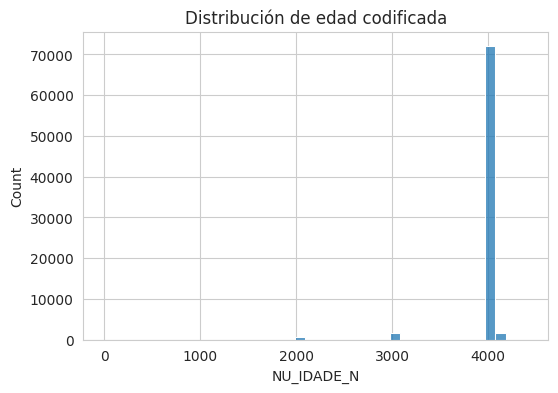

In [393]:
plt.figure(figsize=(6,4))
sns.histplot(df["NU_IDADE_N"], bins=40)
plt.title("Distribución de edad codificada")
plt.show()

In [394]:
# ─────────────────────────────────────────────
# Decodificar edad (formato SINAN brasileño)
#    4XXX = años  |  3XXX = días  |  2XXX = meses  |  1XXX = años
# ─────────────────────────────────────────────
def decode_idade(val):
    if val >= 4000:   return val - 4000
    elif val >= 3000: return (val - 3000) / 365
    elif val >= 2000: return (val - 2000) / 12
    elif val >= 1000: return val - 1000
    else:             return val / 365

df['IDADE_ANOS'] = df['NU_IDADE_N'].apply(decode_idade)
df['IDADE_ANOS'] = df['IDADE_ANOS'].clip(upper=110)   # cap outliers (15 registros > 110 años)
df = df.drop(columns=['NU_IDADE_N'])

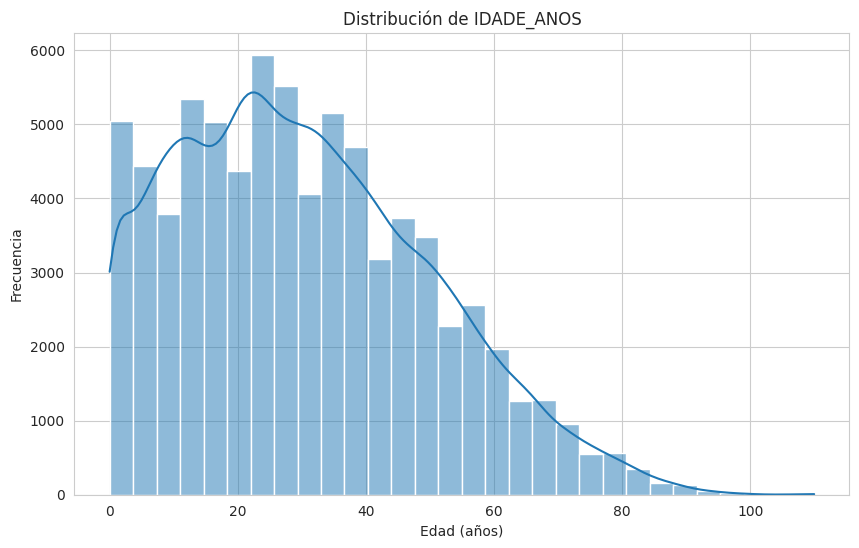

In [395]:
plt.figure(figsize=(10, 6))
sns.histplot(df['IDADE_ANOS'], bins=30, kde=True)
plt.title('Distribución de IDADE_ANOS')
plt.xlabel('Edad (años)')
plt.ylabel('Frecuencia')
plt.show()

La mayoría de los casos se concentran entre 15 y 40 años, con un pico alrededor de 25–30 años. La distribución presenta asimetría hacia la derecha, indicando que existen algunos pacientes de mayor edad pero con menor frecuencia. Esto sugiere que el dataset está dominado por adultos jóvenes.

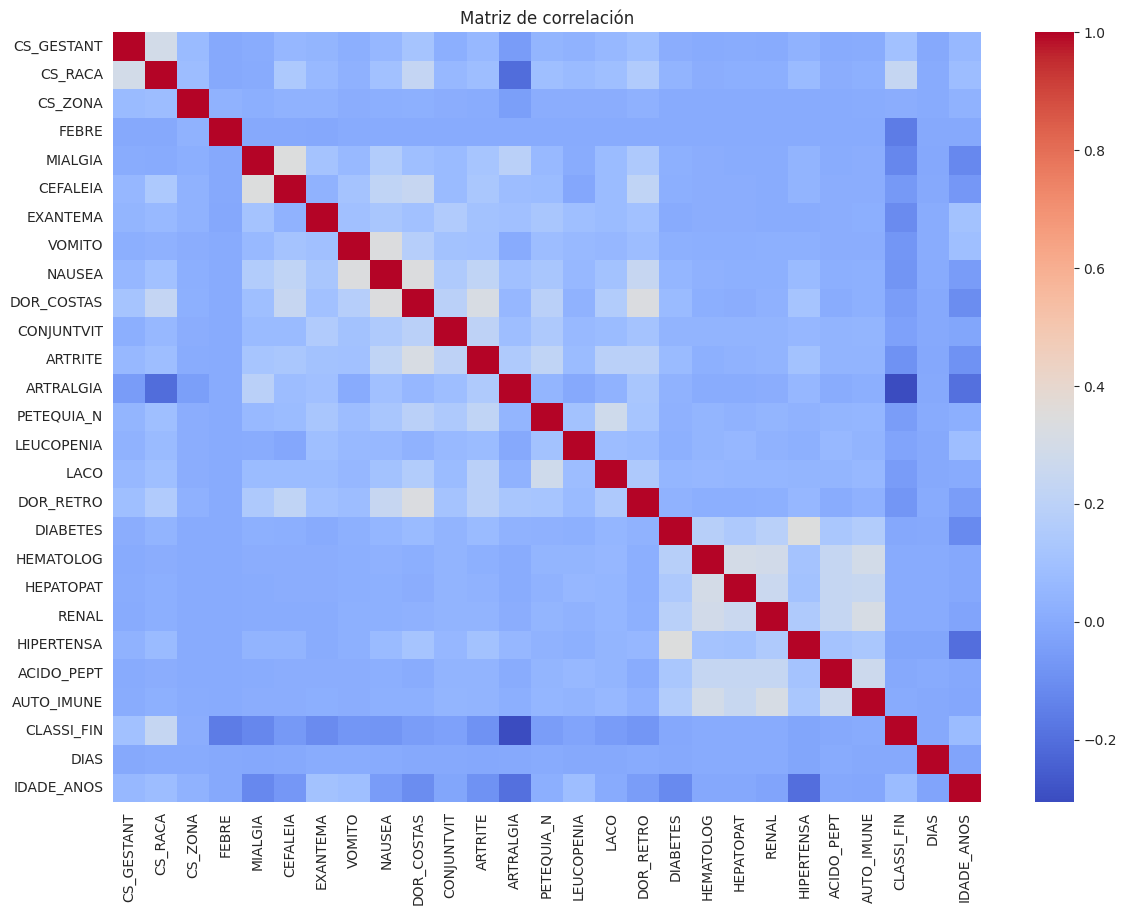

In [396]:
plt.figure(figsize=(14,10))
# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

- Algunas variables relacionadas con síntomas (por ejemplo fiebre, mialgia, cefalea o vómitos) muestran ligeras correlaciones positivas, lo cual es esperable porque estos síntomas pueden aparecer juntos en infecciones virales.

- Las variables asociadas a comorbilidades (diabetes, renal, hipertensión, etc.) también presentan pequeñas correlaciones entre sí.

- La variable objetivo `CLASSI_FIN` no presenta correlaciones fuertes con una sola variable, lo que sugiere que la clasificación de la enfermedad depende de la combinación de varios síntomas y factores, y no de una única característica.

In [397]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 75951 entries, 284 to 277
Data columns (total 28 columns):
 #   Column      Non-Null Count  Dtype          
---  ------      --------------  -----          
 0   CS_SEXO     75948 non-null  object         
 1   CS_GESTANT  75933 non-null  float64        
 2   CS_RACA     75626 non-null  float64        
 3   CS_ZONA     69029 non-null  float64        
 4   FEBRE       75951 non-null  float64        
 5   MIALGIA     75951 non-null  float64        
 6   CEFALEIA    75951 non-null  float64        
 7   EXANTEMA    75951 non-null  float64        
 8   VOMITO      75951 non-null  float64        
 9   NAUSEA      75951 non-null  float64        
 10  DOR_COSTAS  75951 non-null  float64        
 11  CONJUNTVIT  75951 non-null  float64        
 12  ARTRITE     75951 non-null  float64        
 13  ARTRALGIA   75951 non-null  float64        
 14  PETEQUIA_N  75951 non-null  float64        
 15  LEUCOPENIA  75951 non-null  float64        
 16  LACO     

In [398]:

# Convertir la columna 'DIAS' (Timedelta) a una representación numérica (días totales)
# Rellenar cualquier valor NaN que pueda surgir de la conversión o de los datos originales con el valor 9.
df['DIAS'] = df['DIAS'].apply(lambda x: x.days if pd.notna(x) else 9).astype(float)

In [399]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 75951 entries, 284 to 277
Data columns (total 28 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CS_SEXO     75948 non-null  object 
 1   CS_GESTANT  75933 non-null  float64
 2   CS_RACA     75626 non-null  float64
 3   CS_ZONA     69029 non-null  float64
 4   FEBRE       75951 non-null  float64
 5   MIALGIA     75951 non-null  float64
 6   CEFALEIA    75951 non-null  float64
 7   EXANTEMA    75951 non-null  float64
 8   VOMITO      75951 non-null  float64
 9   NAUSEA      75951 non-null  float64
 10  DOR_COSTAS  75951 non-null  float64
 11  CONJUNTVIT  75951 non-null  float64
 12  ARTRITE     75951 non-null  float64
 13  ARTRALGIA   75951 non-null  float64
 14  PETEQUIA_N  75951 non-null  float64
 15  LEUCOPENIA  75951 non-null  float64
 16  LACO        75951 non-null  float64
 17  DOR_RETRO   75951 non-null  float64
 18  DIABETES    75951 non-null  float64
 19  HEMATOLOG   75951 non-null  fl

In [400]:
# ─────────────────────────────────────────────
#  Parsear DIAS => número entero de días
#    Cap en p95 (~113 días) para eliminar errores de fecha
# ─────────────────────────────────────────────
df['DIAS_NUM'] = df['DIAS']
cap_dias = df['DIAS_NUM'].quantile(0.95)
df['DIAS_NUM'] = df['DIAS_NUM'].clip(upper=cap_dias)
df = df.drop(columns=['DIAS'])
print(f"DIAS capado en {cap_dias:.0f} días (p95)")

DIAS capado en 75 días (p95)


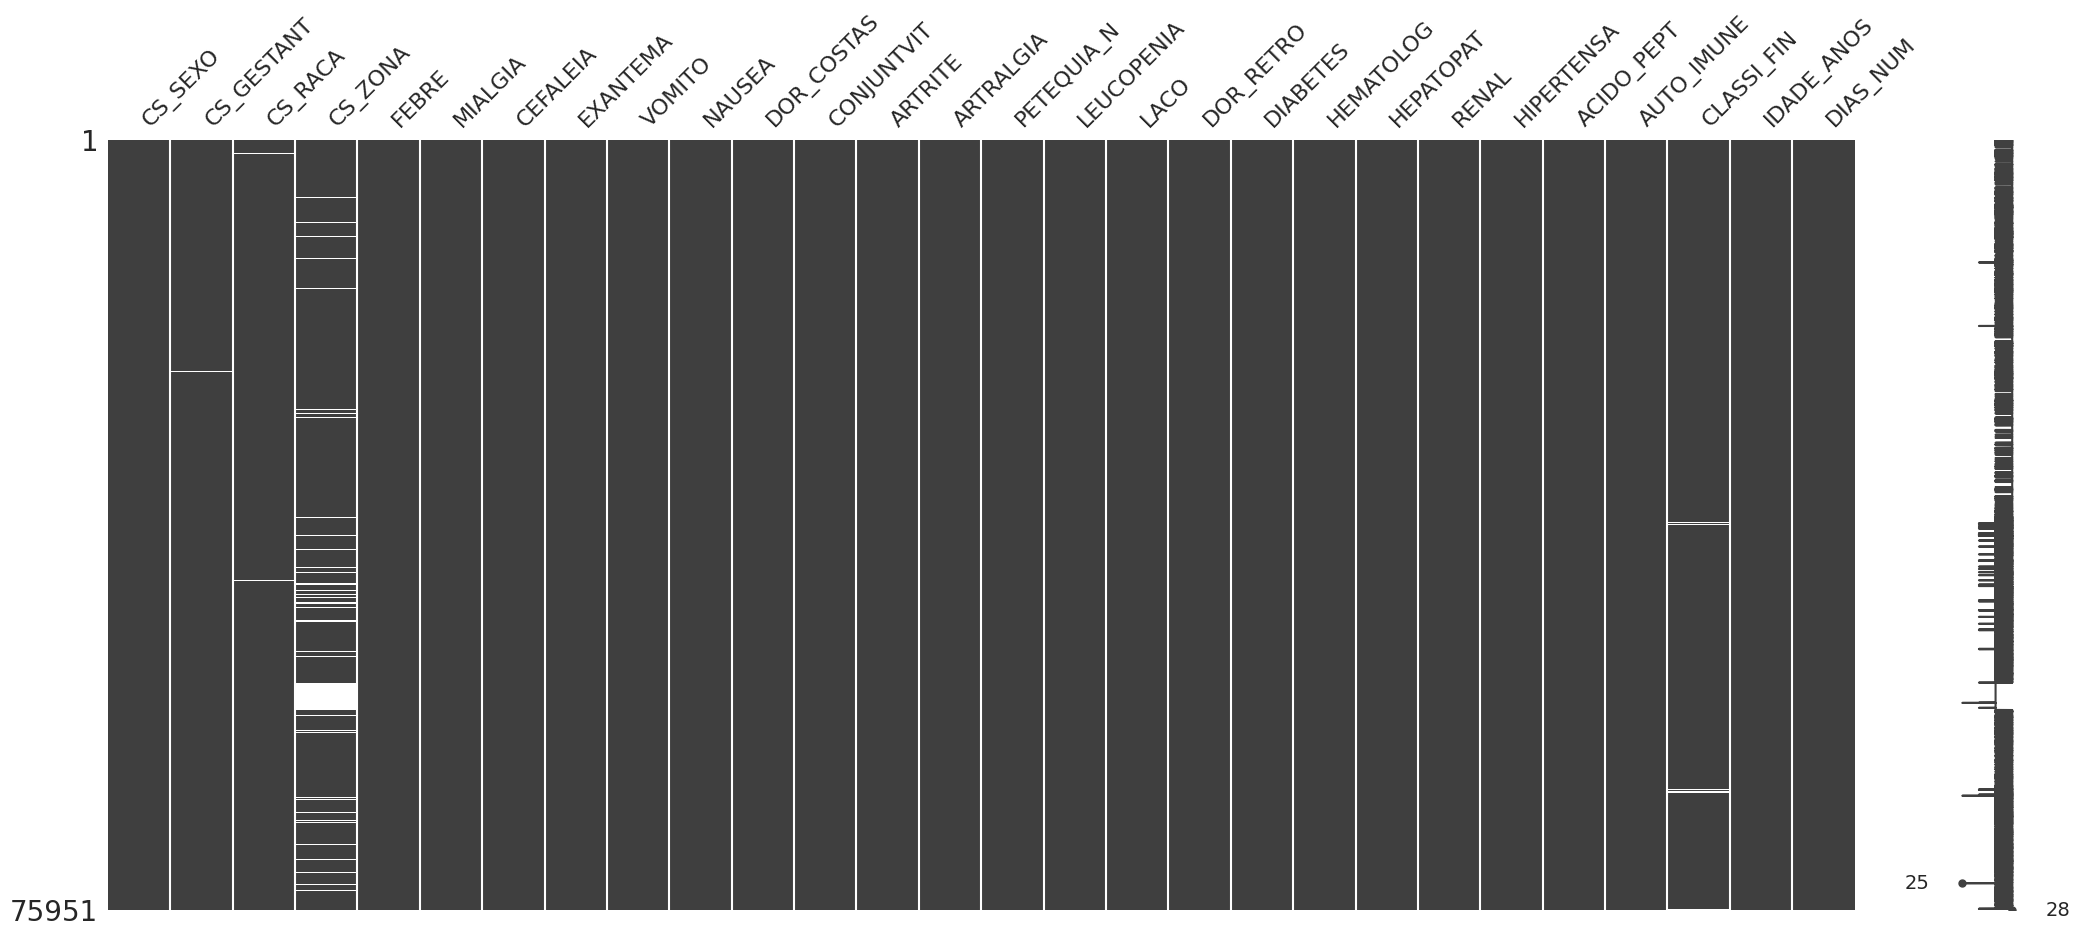

In [401]:
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(df)
plt.show()

In [402]:
df.isnull().sum().sort_values(ascending=False)

,0
CS_ZONA,6922
CLASSI_FIN,625
CS_RACA,325
CS_GESTANT,18
CS_SEXO,3
FEBRE,0
CEFALEIA,0
MIALGIA,0
VOMITO,0
NAUSEA,0


# Filling in null values
Columns that still had null values were filled with the value corresponding to "unfilled" entered in the dictionary.

In [403]:
for name in df.columns:
   df.loc[df[name].isnull(), name] = 9

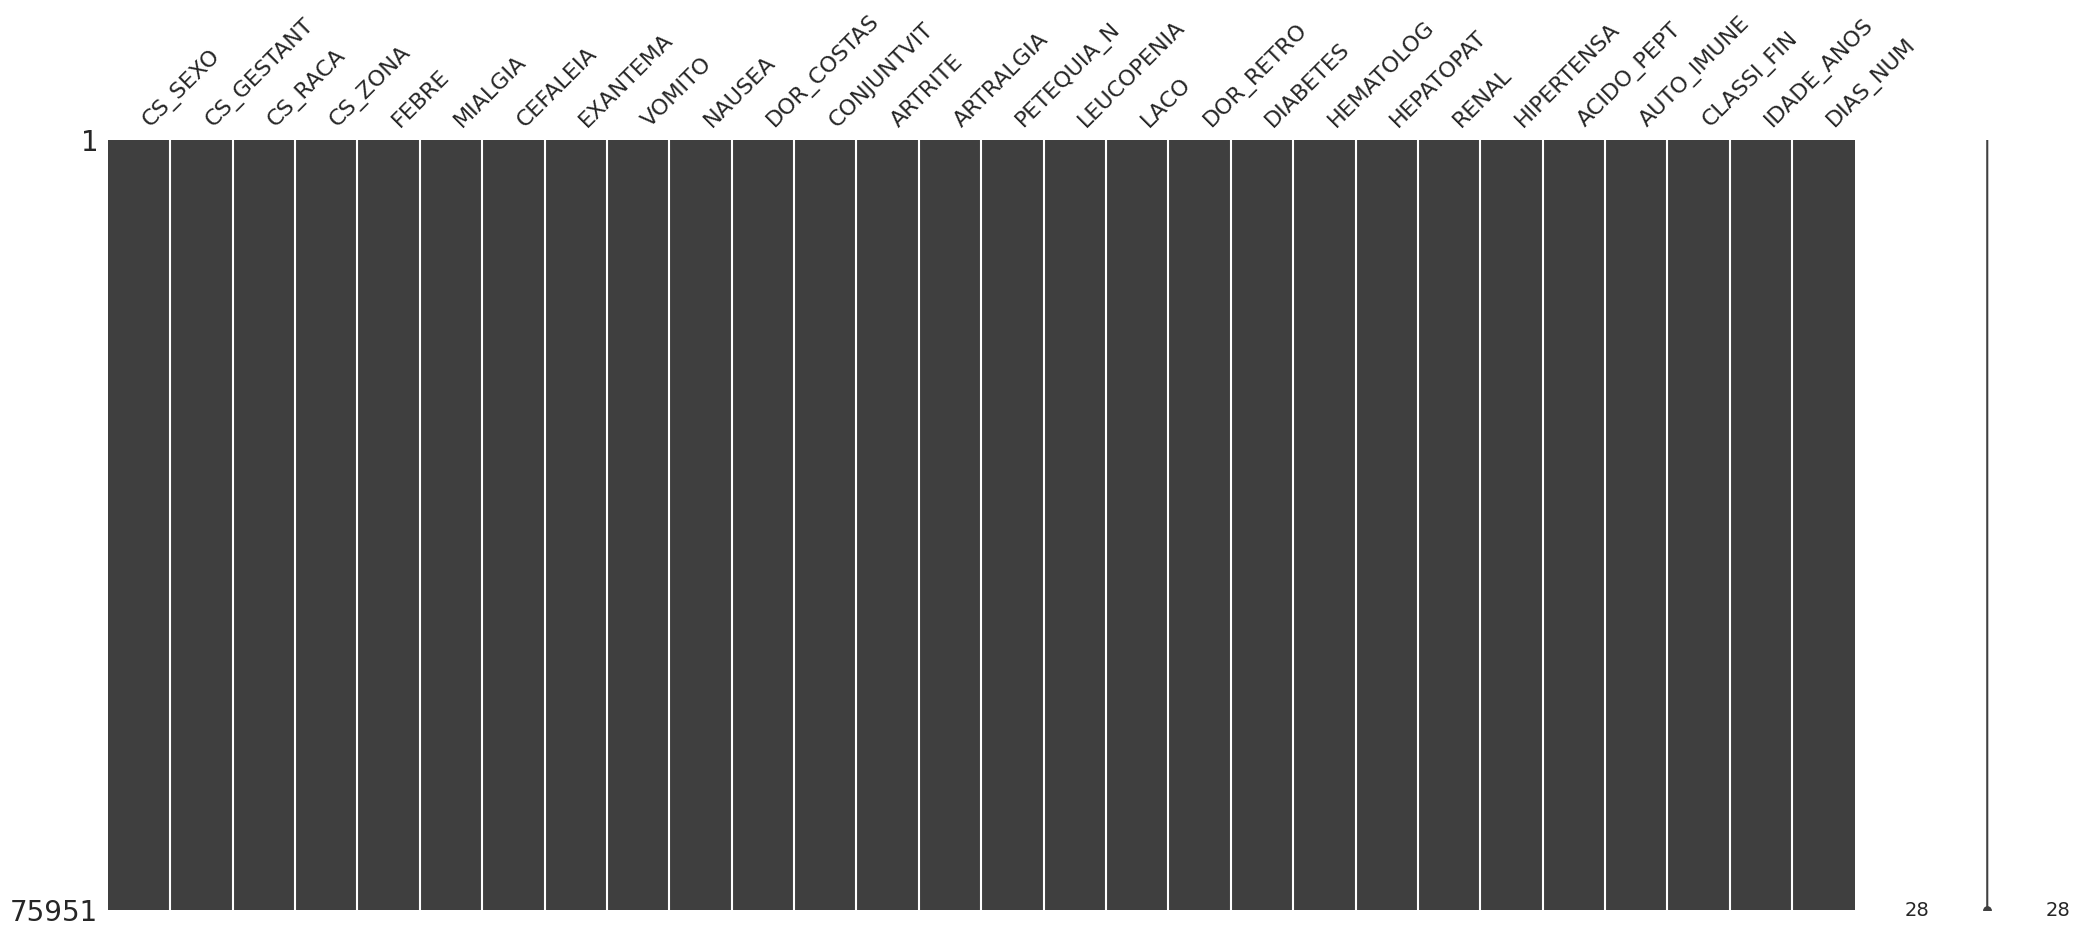

In [404]:
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(df)
plt.show()

In [405]:
# ─────────────────────────────────────────────
# 5. Recodificar síntomas: 1→1 (sí), 2→0 (no)
#    En SINAN: 1 = presente, 2 = ausente
# ─────────────────────────────────────────────
symptom_cols = [
    'FEBRE','MIALGIA','CEFALEIA','EXANTEMA','VOMITO','NAUSEA',
    'DOR_COSTAS','CONJUNTVIT','ARTRITE','ARTRALGIA','PETEQUIA_N',
    'LEUCOPENIA','LACO','DOR_RETRO','DIABETES','HEMATOLOG',
    'HEPATOPAT','RENAL','HIPERTENSA','ACIDO_PEPT','AUTO_IMUNE'
]
for col in symptom_cols:
    df[col] = (df[col] == 1).astype(int)

In [406]:
df.head()

,CS_SEXO,CS_GESTANT,CS_RACA,CS_ZONA,FEBRE,MIALGIA,CEFALEIA,EXANTEMA,VOMITO,NAUSEA,DOR_COSTAS,CONJUNTVIT,ARTRITE,ARTRALGIA,PETEQUIA_N,LEUCOPENIA,LACO,DOR_RETRO,DIABETES,HEMATOLOG,HEPATOPAT,RENAL,HIPERTENSA,ACIDO_PEPT,AUTO_IMUNE,CLASSI_FIN,IDADE_ANOS,DIAS_NUM
284,0,5.0,4.0,1.0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5.0,34.0,28.0
525,0,5.0,4.0,1.0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8.0,29.0,3.0
552,0,4.0,1.0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,10.0,54.0,2.0
608,1,6.0,5.0,1.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5.0,18.0,1.0
1464,0,5.0,4.0,1.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5.0,21.0,3.0


# Estandarización de los resultados en la variable objetivo

La columna CLASSI_FIN contiene distintos valores que corresponden a una misma enfermedad. Por ello, dichos valores fueron agrupados y estandarizados según el tipo de enfermedad correspondiente, con el fin de unificar las categorías.

/tmp/ipykernel_7764/2890704856.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='CLASSI_FIN', palette='viridis')


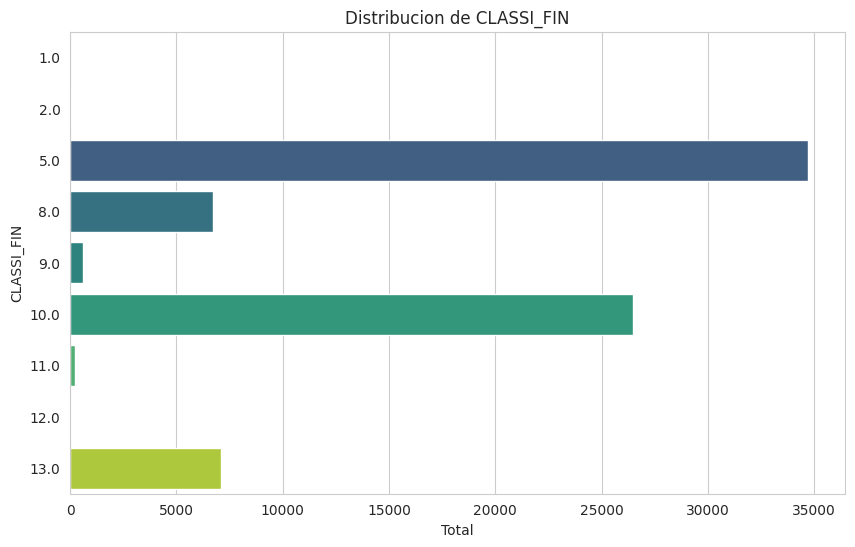

In [407]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='CLASSI_FIN', palette='viridis')
plt.title('Distribucion de CLASSI_FIN')
plt.xlabel('Total')
plt.ylabel('CLASSI_FIN')
plt.show()

In [408]:
# DENGUE
# 1  - Classic Dengue
# 2  - Dengue with complications
# 10 - Dengue
# 11 - Dengue with warning signs
# 12 - Severe Dengue
df.loc[df['CLASSI_FIN'] == 1, 'CLASSI_FIN'] = 'DENGUE'
df.loc[df['CLASSI_FIN'] == 2, 'CLASSI_FIN'] = 'DENGUE'
df.loc[df['CLASSI_FIN'] == 10, 'CLASSI_FIN'] = 'DENGUE'
df.loc[df['CLASSI_FIN'] == 11, 'CLASSI_FIN'] = 'DENGUE'
df.loc[df['CLASSI_FIN'] == 12, 'CLASSI_FIN'] = 'DENGUE'

# CHIKUNGUNYA
# 13 - Chikungunya
df.loc[df['CLASSI_FIN'] == 13, 'CLASSI_FIN'] = 'CHIKUNGUNYA'

# OTHER
# 5 - Discarded
# 8 - Inconclusive
# 9 - Nulos
df.loc[df['CLASSI_FIN'] == 5, 'CLASSI_FIN'] = 'OTHER'
df.loc[df['CLASSI_FIN'] == 8, 'CLASSI_FIN'] = 'OTHER'
df.loc[df['CLASSI_FIN'] == 9, 'CLASSI_FIN'] = 'OTHER'

/tmp/ipykernel_7764/2526162157.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'DENGUE' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df['CLASSI_FIN'] == 1, 'CLASSI_FIN'] = 'DENGUE'


DF columns objeto: 2


/tmp/ipykernel_7764/1098333250.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=counts.index, x=counts.values, palette='viridis')


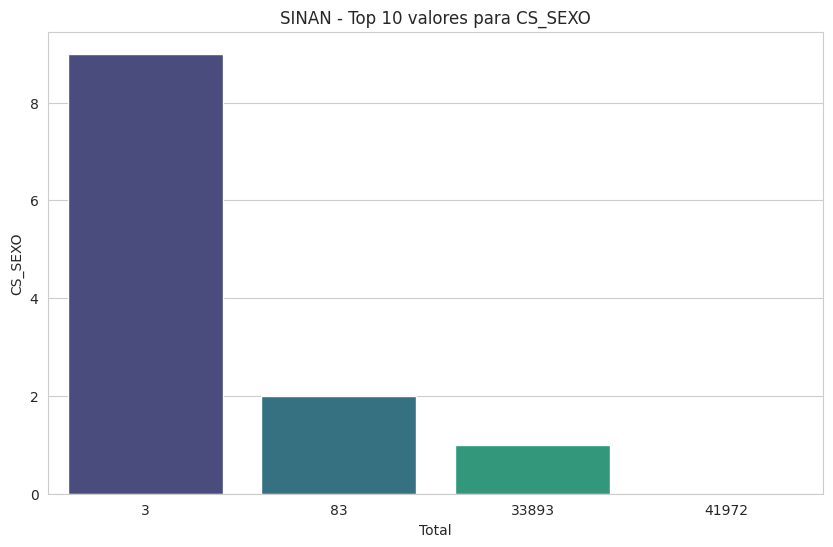

/tmp/ipykernel_7764/1098333250.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=counts.index, x=counts.values, palette='viridis')


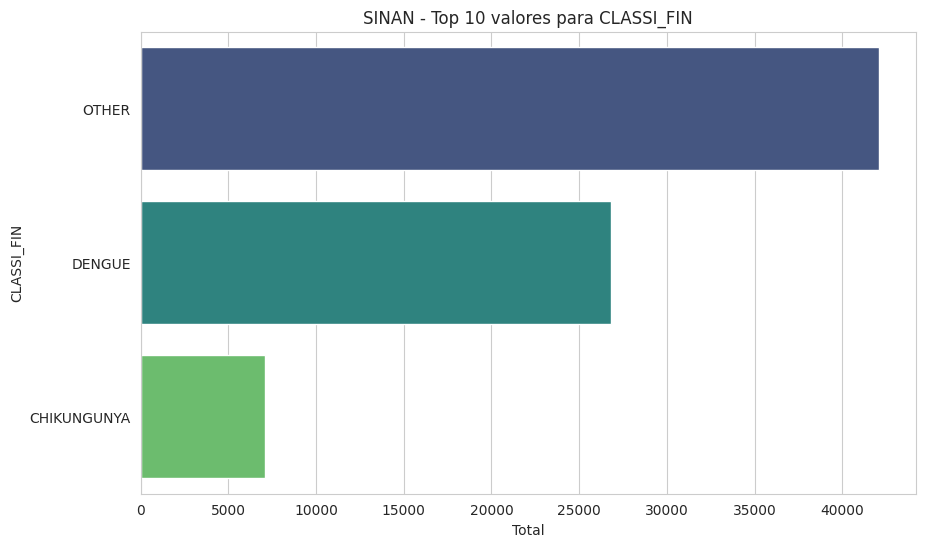

In [409]:
import seaborn as sns
import matplotlib.pyplot as plt

# categóricas más frecuentes

# previsualizacion de columnas tipo Object
df_obj = df.select_dtypes(include="object").columns

print("DF columns objeto:", len(df_obj))

# Show frequency plots for the top 10 values
for col in list(df_obj[:5]):
    plt.figure(figsize=(10, 6))
    # Get the value counts
    counts = df[col].value_counts(dropna=False).head(10)
    # Use sns.barplot to plot the pre-calculated counts
    sns.barplot(y=counts.index, x=counts.values, palette='viridis')
    plt.title(f"SINAN - Top 10 valores para {col}")
    plt.xlabel("Total")
    plt.ylabel(col)
    plt.show()

In [410]:
# categóricas más frecuentes

# Object columns preview
df_obj = df.select_dtypes(include="object").columns

print("DF object columns:", len(df_obj))

# Show some frequency tables
for col in list(df_obj[:5]):
    print(f"\nSINAN - Top values for {col}")
    display(df[col].value_counts(dropna=False).head(10))

DF object columns: 2

SINAN - Top values for CS_SEXO


,count
CS_SEXO,
0,41972
1,33893
2,83
9,3



SINAN - Top values for CLASSI_FIN


,count
CLASSI_FIN,
OTHER,42063
DENGUE,26793
CHIKUNGUNYA,7095


In [411]:
df.shape

(75951, 28)

In [412]:

df.head()

,CS_SEXO,CS_GESTANT,CS_RACA,CS_ZONA,FEBRE,MIALGIA,CEFALEIA,EXANTEMA,VOMITO,NAUSEA,DOR_COSTAS,CONJUNTVIT,ARTRITE,ARTRALGIA,PETEQUIA_N,LEUCOPENIA,LACO,DOR_RETRO,DIABETES,HEMATOLOG,HEPATOPAT,RENAL,HIPERTENSA,ACIDO_PEPT,AUTO_IMUNE,CLASSI_FIN,IDADE_ANOS,DIAS_NUM
284,0,5.0,4.0,1.0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,OTHER,34.0,28.0
525,0,5.0,4.0,1.0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,OTHER,29.0,3.0
552,0,4.0,1.0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,DENGUE,54.0,2.0
608,1,6.0,5.0,1.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,OTHER,18.0,1.0
1464,0,5.0,4.0,1.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,OTHER,21.0,3.0


In [413]:
df.to_csv('data_set_unbalanced.csv', sep=';', index=False)

# Aplicación de undersampling (no aplicamos porque llegaba a 0.64 accuracy)

Aplicando la técnica de undersampling para equilibrar (balancear) los datos

In [414]:
'''
# Convert the 9.0 float values in 'CLASSI_FIN' to a string 'UNKNOWN'
df.loc[df['CLASSI_FIN'] == 9.0, 'CLASSI_FIN'] = 'UNKNOWN'


# Shows that the data set is unbalanced
print(Counter(df.CLASSI_FIN))

X = df.drop('CLASSI_FIN', axis=1)
Y = df.CLASSI_FIN

# Ensure all columns in X are numeric. Coerce non-numeric values to NaN and then fill NaNs.
X = X.apply(pd.to_numeric, errors='coerce').fillna(9)

X = np.array(X)
Y = np.array(Y)

# define undersample strategy
undersample = RandomUnderSampler(sampling_strategy='not minority')
# fit and apply the transform
X_under, y_under = undersample.fit_resample(X, Y)
# summarize class distribution
print(Counter(y_under))

# Transforming the undersampling base into a dataframe to save the csv

myData = np.c_[X_under, y_under]
columns = df.drop('CLASSI_FIN', axis=1).columns.tolist()
columns.append('CLASSI_FIN')

df = pd.DataFrame(data=myData, columns=columns)
df
'''

"\n# Convert the 9.0 float values in 'CLASSI_FIN' to a string 'UNKNOWN'\ndf.loc[df['CLASSI_FIN'] == 9.0, 'CLASSI_FIN'] = 'UNKNOWN'\n\n\n# Shows that the data set is unbalanced\nprint(Counter(df.CLASSI_FIN))\n\nX = df.drop('CLASSI_FIN', axis=1)\nY = df.CLASSI_FIN\n\n# Ensure all columns in X are numeric. Coerce non-numeric values to NaN and then fill NaNs.\nX = X.apply(pd.to_numeric, errors='coerce').fillna(9)\n\nX = np.array(X)\nY = np.array(Y)\n\n# define undersample strategy\nundersample = RandomUnderSampler(sampling_strategy='not minority')\n# fit and apply the transform\nX_under, y_under = undersample.fit_resample(X, Y)\n# summarize class distribution\nprint(Counter(y_under))\n\n# Transforming the undersampling base into a dataframe to save the csv\n\nmyData = np.c_[X_under, y_under]\ncolumns = df.drop('CLASSI_FIN', axis=1).columns.tolist()\ncolumns.append('CLASSI_FIN')\n\ndf = pd.DataFrame(data=myData, columns=columns)\ndf\n"

# Guardar bvalanceado

In [415]:
df.to_csv('data_set_balanced.csv', sep=';', index=False)